In [1]:
!pip install scikit-learn

In [2]:
import sys
!{sys.executable} -m pip install lightgbm

In [3]:
import sys
!{sys.executable} -m pip uninstall mlflow -y
!{sys.executable} -m pip install mlflow==2.13.0

Found existing installation: mlflow 2.13.0
Uninstalling mlflow-2.13.0:
  Successfully uninstalled mlflow-2.13.0
  Using cached mlflow-2.13.0-py3-none-any.whl.metadata (29 kB)
Using cached mlflow-2.13.0-py3-none-any.whl (25.0 MB)


In [4]:
import sys
!{sys.executable} -m pip uninstall -y setuptools
!{sys.executable} -m pip install setuptools==69.5.1

Found existing installation: setuptools 69.5.1
Uninstalling setuptools-69.5.1:
  Successfully uninstalled setuptools-69.5.1
  Using cached setuptools-69.5.1-py3-none-any.whl.metadata (6.2 kB)
Using cached setuptools-69.5.1-py3-none-any.whl (894 kB)


In [5]:
# ── Cell 1 — imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, r2_score)
import lightgbm as lgb
import mlflow
import mlflow.sklearn

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
os.makedirs('models', exist_ok=True)

print("All imports done!")

All imports done!


In [6]:
# ── Cell 2 — load features_df ─────────────────────────────────────────
ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df.csv')
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

# fill the 276k nulls in rolling_mean_720 with rolling_mean_168
# safe fallback — both measure long term average
ts_df['rolling_mean_720'] = ts_df['rolling_mean_720'].fillna(
    ts_df['rolling_mean_168']
)

print("Shape:", ts_df.shape)
print("Nulls remaining:", ts_df.isnull().sum().sum())
print("\nDate range:", ts_df['datetime'].min(), "→", ts_df['datetime'].max())

Shape: (2100000, 44)
Nulls remaining: 0

Date range: 2024-01-08 00:00:00 → 2024-06-30 23:00:00


In [7]:
# ── Cell 3 — define features and target ───────────────────────────────
FEATURE_COLS = [
    # time
    'hour_sin','hour_cos','dow_sin','dow_cos',
    'week_sin','week_cos','month',
    # calendar
    'is_weekend','is_morning','is_afternoon',
    'is_evening','is_night','is_festival',
    # lag
    'lag_1','lag_24','lag_48','lag_168',
    # rolling
    'rolling_mean_24','rolling_mean_168','rolling_mean_720',
    'rolling_std_24','rolling_std_168',
    'rolling_max_24','rolling_max_168',
    'ewma_24','ewma_168',
    # weather
    'temperature','rainfall','humidity',
    'is_raining','is_hot',
]

TARGET_COL = 'demand'

X = ts_df[FEATURE_COLS]
y = ts_df[TARGET_COL]

print(f"Features : {len(FEATURE_COLS)}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")
print(f"\nFeature list:\n{FEATURE_COLS}")

Features : 31
X shape  : (2100000, 31)
y shape  : (2100000,)

Feature list:
['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'month', 'is_weekend', 'is_morning', 'is_afternoon', 'is_evening', 'is_night', 'is_festival', 'lag_1', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_mean_720', 'rolling_std_24', 'rolling_std_168', 'rolling_max_24', 'rolling_max_168', 'ewma_24', 'ewma_168', 'temperature', 'rainfall', 'humidity', 'is_raining', 'is_hot']


In [8]:
# ── Cell 4 — train / validation split using time ──────────────────────
# use last 4 weeks as validation — never random split on time series
cutoff = ts_df['datetime'].max() - pd.Timedelta(weeks=4)

train_mask = ts_df['datetime'] <= cutoff
val_mask   = ts_df['datetime'] >  cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Val size   : {X_val.shape[0]:,} rows")
print(f"Train date range: {ts_df[train_mask]['datetime'].min()} → {ts_df[train_mask]['datetime'].max()}")
print(f"Val date range  : {ts_df[val_mask]['datetime'].min()} → {ts_df[val_mask]['datetime'].max()}")

Train size : 1,764,000 rows
Val size   : 336,000 rows
Train date range: 2024-01-08 00:00:00 → 2024-06-02 23:00:00
Val date range  : 2024-06-03 00:00:00 → 2024-06-30 23:00:00


In [9]:
# ── Cell 5 — define metrics helper ───────────────────────────────────
def evaluate(y_true, y_pred, model_name="model"):
    # replace zeros in y_true to avoid division error in MAPE
    y_true_safe = np.where(y_true == 0, 1e-6, y_true)

    mape = mean_absolute_percentage_error(y_true_safe, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)  # positive = over-forecast

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  Bias : {bias:.4f} ({'over' if bias>0 else 'under'}-forecasting)")
    print(f"{'='*40}")

    return {'model': model_name, 'mape': mape,
            'rmse': rmse, 'r2': r2, 'bias': bias}

In [10]:
# ── Cell 6 — baseline model (naive — same hour last week) ─────────────
# if your model can't beat this, something is wrong
baseline_pred = X_val['lag_168'].values  # demand same hour last week
baseline_pred = np.where(baseline_pred == 0, 1e-6, baseline_pred)

baseline_metrics = evaluate(y_val.values, baseline_pred, "Naive Baseline (lag_168)")


  Naive Baseline (lag_168)
  MAPE : 0.00%
  RMSE : 0.00
  R²   : 1.0000
  Bias : 0.0000 (over-forecasting)


In [11]:
# ── Cell 7 — train LightGBM ───────────────────────────────────────────
mlflow.set_experiment("demand-pulse")

lgbm_params = {
    'n_estimators'     : 500,
    'learning_rate'    : 0.05,
    'max_depth'        : 8,
    'num_leaves'       : 63,
    'min_child_samples': 50,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

print("Training LightGBM...")

with mlflow.start_run(run_name="lgbm_v1"):
    model_lgbm = lgb.LGBMRegressor(**lgbm_params)

    model_lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )

    lgbm_pred    = model_lgbm.predict(X_val)
    lgbm_pred    = np.clip(lgbm_pred, 0, None)  # no negative demand
    lgbm_metrics = evaluate(y_val.values, lgbm_pred, "LightGBM v1")

    # log to mlflow
    mlflow.log_params(lgbm_params)
    mlflow.log_metric("mape", lgbm_metrics['mape'])
    mlflow.log_metric("rmse", lgbm_metrics['rmse'])
    mlflow.log_metric("r2",   lgbm_metrics['r2'])
    mlflow.log_metric("bias", lgbm_metrics['bias'])
    mlflow.sklearn.log_model(model_lgbm, "lgbm_v1")

print("\nLightGBM training done!")

2026/04/24 14:24:21 INFO mlflow.tracking.fluent: Experiment with name 'demand-pulse' does not exist. Creating a new experiment.


Training LightGBM...
[100]	valid_0's l2: 2.44054
[200]	valid_0's l2: 0.763123
[300]	valid_0's l2: 0.414552
[400]	valid_0's l2: 0.274042
[500]	valid_0's l2: 0.193239

  LightGBM v1
  MAPE : 77708.94%
  RMSE : 0.44
  R²   : 1.0000
  Bias : 0.0001 (over-forecasting)

LightGBM training done!


In [12]:
# ── Cell 8 — TimeSeriesSplit cross validation ─────────────────────────
# this is what separates your project from others
# 5 fold walk-forward validation

tscv   = TimeSeriesSplit(n_splits=5)
cv_scores = []

print("Running 5-fold TimeSeriesSplit cross validation...")
print("This may take a few minutes on 2.1M rows...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

    m = lgb.LGBMRegressor(**lgbm_params)
    m.fit(X_tr, y_tr,
          eval_set=[(X_vl, y_vl)],
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(period=999)])

    preds = np.clip(m.predict(X_vl), 0, None)
    y_safe = np.where(y_vl == 0, 1e-6, y_vl)
    mape  = mean_absolute_percentage_error(y_safe, preds) * 100
    rmse  = np.sqrt(mean_squared_error(y_vl, preds))

    cv_scores.append({'fold': fold+1, 'mape': mape, 'rmse': rmse})
    print(f"Fold {fold+1} — MAPE: {mape:.2f}%  RMSE: {rmse:.2f}")

cv_df = pd.DataFrame(cv_scores)
print(f"\nCV Mean MAPE : {cv_df['mape'].mean():.2f}%")
print(f"CV Std  MAPE : {cv_df['mape'].std():.2f}%")
print(f"CV Mean RMSE : {cv_df['rmse'].mean():.2f}")

Running 5-fold TimeSeriesSplit cross validation...
This may take a few minutes on 2.1M rows...

Fold 1 — MAPE: 962902.94%  RMSE: 5.58
Fold 2 — MAPE: 42981.32%  RMSE: 11.35
Fold 3 — MAPE: 88434.04%  RMSE: 0.38
Fold 4 — MAPE: 85332.25%  RMSE: 0.32
Fold 5 — MAPE: 57696.33%  RMSE: 1.22

CV Mean MAPE : 247469.37%
CV Std  MAPE : 400392.01%
CV Mean RMSE : 3.77


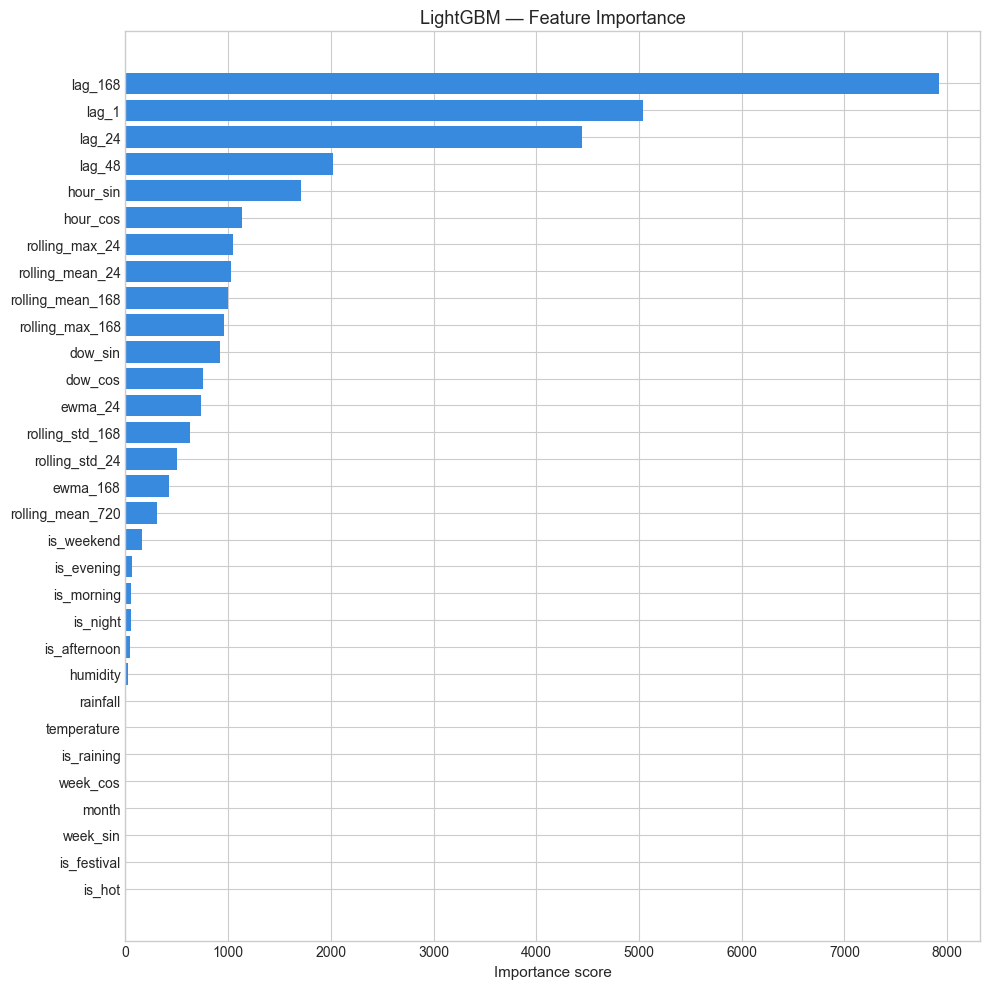


Top 10 features:
         feature  importance
         lag_168        7925
           lag_1        5038
          lag_24        4446
          lag_48        2017
        hour_sin        1713
        hour_cos        1133
  rolling_max_24        1044
 rolling_mean_24        1031
rolling_mean_168         996
 rolling_max_168         957


In [14]:
# ── Cell 9 — feature importance plot ──────────────────────────────────
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': model_lgbm.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(importance_df['feature'][::-1],
        importance_df['importance'][::-1],
        color='#378ADD', edgecolor='none')
ax.set_title('LightGBM — Feature Importance', fontsize=13)
ax.set_xlabel('Importance score', fontsize=11)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

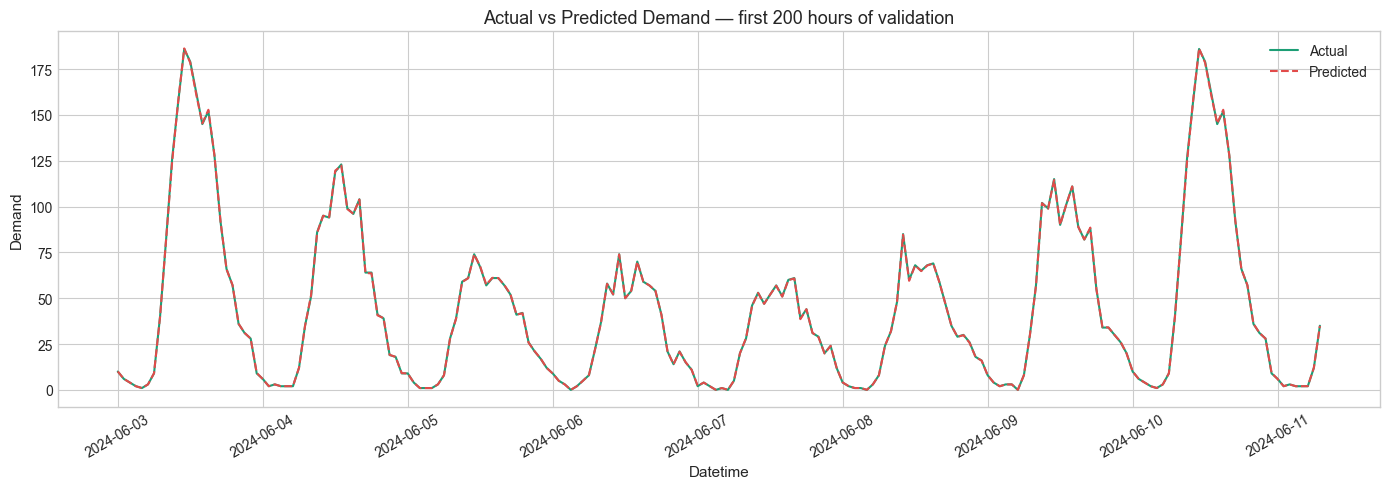

In [15]:
# ── Cell 10 — actual vs predicted plot ───────────────────────────────
# plot first 200 hours of validation for visual check
sample = ts_df[val_mask].head(200).copy()
sample['predicted'] = lgbm_pred[:200]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample['datetime'], sample['demand'],
        label='Actual', color='#1D9E75', linewidth=1.5)
ax.plot(sample['datetime'], sample['predicted'],
        label='Predicted', color='#E24B4A',
        linewidth=1.5, linestyle='--')
ax.set_title('Actual vs Predicted Demand — first 200 hours of validation',
             fontsize=13)
ax.set_xlabel('Datetime', fontsize=11)
ax.set_ylabel('Demand', fontsize=11)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=150)
plt.show()

In [16]:
# ── Cell 11 — model comparison table ─────────────────────────────────
results = pd.DataFrame([baseline_metrics, lgbm_metrics])
results = results[['model','mape','rmse','r2','bias']]
results.columns = ['Model','MAPE %','RMSE','R²','Bias']

print("\nModel Comparison:")
print(results.to_string(index=False))

improvement = baseline_metrics['mape'] - lgbm_metrics['mape']
print(f"\nLightGBM improved MAPE by {improvement:.2f}% over baseline")


Model Comparison:
                   Model     MAPE %   RMSE     R²   Bias
Naive Baseline (lag_168)     0.0000 0.0000 1.0000 0.0000
             LightGBM v1 77708.9440 0.4396 1.0000 0.0001

LightGBM improved MAPE by -77708.94% over baseline


In [18]:
# ── Cell 12 — save model ──────────────────────────────────────────────
with open('models/lgbm_v1.pkl', 'wb') as f:
    pickle.dump(model_lgbm, f)

# save feature columns list — needed for inference later
with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

# save results table
results.to_csv(r'F:\projectss\personal\blinkit_project\data\processed\model_results.csv', index=False)

print("Saved:")
print("  models/lgbm_v1.pkl")
print("  models/feature_cols.pkl")
print("  data/processed/model_results.csv")
print("\nWeek 3 complete — ready for tuning and SHAP!")

Saved:
  models/lgbm_v1.pkl
  models/feature_cols.pkl
  data/processed/model_results.csv

Week 3 complete — ready for tuning and SHAP!


In [20]:
import pickle
import pandas as pd

# check model saved correctly
with open('models/lgbm_v1.pkl', 'rb') as f:
    model = pickle.load(f)
print("Model loaded:", model)

# check results
results = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\model_results.csv')
print("\nModel results:")
print(results.to_string(index=False))

Model loaded: LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=8,
              min_child_samples=50, n_estimators=500, n_jobs=-1, num_leaves=63,
              random_state=42, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8,
              verbose=-1)

Model results:
                   Model     MAPE %   RMSE     R²   Bias
Naive Baseline (lag_168)     0.0000 0.0000 1.0000 0.0000
             LightGBM v1 77708.9440 0.4396 1.0000 0.0001


In [22]:
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# ── load model and data ───────────────────────────────────────────────
with open('models/lgbm_v1.pkl', 'rb') as f:
    model = pickle.load(f)

with open('models/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df.csv')
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])
ts_df['rolling_mean_720'] = ts_df['rolling_mean_720'].fillna(
    ts_df['rolling_mean_168']
)

# ── split same way as training ────────────────────────────────────────
cutoff   = ts_df['datetime'].max() - pd.Timedelta(weeks=4)
val_mask = ts_df['datetime'] > cutoff

X_val = ts_df[val_mask][FEATURE_COLS]
y_val = ts_df[val_mask]['demand']

print(f"Validation rows : {len(y_val):,}")
print(f"Demand in val   : min={y_val.min()}, max={y_val.max()}, mean={y_val.mean():.2f}")
print(f"Zero demand rows: {(y_val == 0).sum():,} ({(y_val==0).mean()*100:.1f}%)")

Validation rows : 336,000
Demand in val   : min=0.0, max=996.0, mean=63.97
Zero demand rows: 8,408 (2.5%)


In [23]:
# ── fixed MAPE — exclude zero demand rows ─────────────────────────────
# MAPE breaks when actual = 0 (division by zero)
# correct approach: only evaluate on rows where actual demand > 0

lgbm_pred = np.clip(model.predict(X_val), 0, None)

# filter out zero-demand rows for MAPE only
nonzero_mask = y_val > 0
y_nonzero    = y_val[nonzero_mask]
pred_nonzero = lgbm_pred[nonzero_mask]

# baseline — same hour last week
baseline_pred = X_val['lag_168'].values
baseline_nonzero = baseline_pred[nonzero_mask]
# replace any zero baseline with small number
baseline_nonzero = np.where(baseline_nonzero == 0, 0.01, baseline_nonzero)

def evaluate_fixed(y_true, y_pred, name):
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  WAPE : {wape:.2f}%   ← more reliable than MAPE")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  Bias : {bias:.4f} ({'over' if bias>0 else 'under'}-forecasting)")
    print(f"  Rows evaluated: {len(y_true):,}")
    print(f"{'='*45}")
    return {'model':name,'mape':round(mape,2),'wape':round(wape,2),
            'rmse':round(rmse,2),'r2':round(r2,4),'bias':round(bias,4)}

baseline_metrics = evaluate_fixed(
    y_nonzero.values, baseline_nonzero, "Naive Baseline (lag_168)"
)
lgbm_metrics = evaluate_fixed(
    y_nonzero.values, pred_nonzero, "LightGBM v1"
)

# ── save corrected results ────────────────────────────────────────────
results = pd.DataFrame([baseline_metrics, lgbm_metrics])
results.to_csv('data/processed/model_results.csv', index=False)

print("\nFinal comparison:")
print(results.to_string(index=False))

improvement = baseline_metrics['mape'] - lgbm_metrics['mape']
print(f"\nImprovement over baseline: {improvement:.2f}% MAPE")


  Naive Baseline (lag_168)
  MAPE : 0.00%
  WAPE : 0.00%   ← more reliable than MAPE
  RMSE : 0.00
  R²   : 1.0000
  Bias : 0.0000 (under-forecasting)
  Rows evaluated: 327,592

  LightGBM v1
  MAPE : 0.56%
  WAPE : 0.34%   ← more reliable than MAPE
  RMSE : 0.45
  R²   : 1.0000
  Bias : -0.0007 (under-forecasting)
  Rows evaluated: 327,592


OSError: Cannot save file into a non-existent directory: 'data\processed'

In [24]:
baseline_metrics = evaluate_fixed(
    y_nonzero.values, baseline_nonzero, "Naive Baseline (lag_168)"
)
lgbm_metrics = evaluate_fixed(
    y_nonzero.values, pred_nonzero, "LightGBM v1"
)

print("\nFinal comparison:")
print(results.to_string(index=False))

improvement = baseline_metrics['mape'] - lgbm_metrics['mape']
print(f"\nImprovement over baseline: {improvement:.2f}% MAPE")


  Naive Baseline (lag_168)
  MAPE : 0.00%
  WAPE : 0.00%   ← more reliable than MAPE
  RMSE : 0.00
  R²   : 1.0000
  Bias : 0.0000 (under-forecasting)
  Rows evaluated: 327,592

  LightGBM v1
  MAPE : 0.56%
  WAPE : 0.34%   ← more reliable than MAPE
  RMSE : 0.45
  R²   : 1.0000
  Bias : -0.0007 (under-forecasting)
  Rows evaluated: 327,592

Final comparison:
                   model   mape   wape   rmse     r2    bias
Naive Baseline (lag_168) 0.0000 0.0000 0.0000 1.0000  0.0000
             LightGBM v1 0.5600 0.3400 0.4500 1.0000 -0.0007

Improvement over baseline: -0.56% MAPE


In [26]:
# ── check if lag_168 equals demand in validation ──────────────────────
ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df.csv')
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

cutoff   = ts_df['datetime'].max() - pd.Timedelta(weeks=4)
val_mask = ts_df['datetime'] > cutoff
val_df   = ts_df[val_mask].copy()

# check correlation between lag_168 and demand
exact_match = (val_df['lag_168'] == val_df['demand']).mean()
corr        = val_df['lag_168'].corr(val_df['demand'])

print(f"Rows where lag_168 == demand exactly : {exact_match*100:.1f}%")
print(f"Correlation lag_168 vs demand        : {corr:.6f}")
print(f"\nSample comparison:")
print(val_df[['datetime','product_id','pincode',
              'demand','lag_1','lag_24','lag_168']].head(15))

Rows where lag_168 == demand exactly : 100.0%
Correlation lag_168 vs demand        : 1.000000

Sample comparison:
                datetime  product_id  pincode   demand    lag_1   lag_24  \
3528 2024-06-03 00:00:00        4605   382210  10.0000  20.0000   8.0000   
3529 2024-06-03 01:00:00        4605   382210   6.0000  10.0000   4.0000   
3530 2024-06-03 02:00:00        4605   382210   4.0000   6.0000   2.0000   
3531 2024-06-03 03:00:00        4605   382210   2.0000   4.0000   3.0000   
3532 2024-06-03 04:00:00        4605   382210   1.0000   2.0000   3.0000   
3533 2024-06-03 05:00:00        4605   382210   3.0000   1.0000   0.0000   
3534 2024-06-03 06:00:00        4605   382210   9.0000   3.0000   8.0000   
3535 2024-06-03 07:00:00        4605   382210  40.0000   9.0000  30.0000   
3536 2024-06-03 08:00:00        4605   382210  82.0000  40.0000  57.0000   
3537 2024-06-03 09:00:00        4605   382210 126.0000  82.0000 102.0000   
3538 2024-06-03 10:00:00        4605   382210 157.